# Method D — Synthetic Difference-in-Differences (SDID)
## Unit Weights + Time Weights (Arkhangelsky et al., 2021)

**What this notebook does:**  
SDID extends both standard DiD and SCM by solving for two sets of weights simultaneously:

1. **Unit weights (λ)** — weight donors so their pre-period trajectory matches NATCOR's pre-period trajectory (same as SCM).
2. **Time weights (ω)** — up-weight pre-period months whose donor values most closely resemble the post-period donor values. This removes pre-period time shocks that don't persist into the post-period.

The ATT estimator is:  
`τ_SDID = (Ȳ_NATCOR,post − Σ_t ω_t·Y_NATCOR,t) − Σ_j λ_j·(Ȳ_j,post − Σ_t ω_t·Y_j,t)`

With 5 donors, SDID can now assign meaningful unit weights across the donor pool rather than defaulting everything to one corridor.

**Structure:**
1. Environment & imports  
2. Shared utility functions  
3. Data loading & audit  
4. Step 1 — Unit weights (λ)  
5. Step 2 — Time weights (ω)  
6. Step 3 — SDID ATT & per-period counterfactual  
7. Jackknife standard error  
8. Figure 1 — Main diagnostic panel  
9. Validation A — In-time placebo tests  
10. Validation B — Leave-one-out donor stability  
11. Final summary table

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Environment & Imports
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
import os
import warnings
warnings.filterwarnings('ignore')

FIG_DIR = '../method_A_graph'
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--', 'font.size': 10,
})
BLUE  = '#0f3460'
RED   = '#e94560'
GREY  = '#aaaaaa'
GREEN = '#2ecc71'
AMBER = '#f39c12'
PURP  = '#9b59b6'

print("All imports successful.")
print(f"NumPy {np.__version__}  |  Pandas {pd.__version__}")
print(f"Figures will save to: {os.path.abspath(FIG_DIR)}")

All imports successful.
NumPy 2.4.2  |  Pandas 3.0.0
Figures will save to: /Users/sitta/Desktop/coding/thesis/method_A_graph


**What is happening here**  
Libraries are imported and the output folder is confirmed. SDID is the most computationally demanding method in this series because it runs two separate optimisations (one for unit weights, one for time weights) and then a jackknife that repeats both for every dropped year.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Shared Utility Functions
# ═══════════════════════════════════════════════════════════════════════════════

def fit_unit_weights(Y_nat_pre, X_donors_pre, lam_u=None):
    """
    SDID unit weights λ: find λ_j >= 0, Σλ_j = 1 minimising
    ||Y_nat_pre − Σ_j λ_j * X_j_pre||^2 + lam_u * ||λ||^2.
    If lam_u is None, Arkhangelsky et al. data-driven formula is used:
      lam_u = (N_donors * T_post)^(1/4) * σ̂
    """
    if X_donors_pre.ndim == 1:
        X_donors_pre = X_donors_pre.reshape(-1, 1)
    T_pre_l, N_d = X_donors_pre.shape
    if lam_u is None:
        sigma_hat = np.std(Y_nat_pre - X_donors_pre.mean(axis=1))
        lam_u = 0.0   # set to 0; with multiple donors the residuals are smaller
    def loss(w):
        return np.mean((Y_nat_pre - X_donors_pre @ w)**2) + lam_u * np.sum(w**2)
    res = minimize(
        loss, np.ones(N_d) / N_d, method='SLSQP',
        bounds=[(0.0, 1.0)] * N_d,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1.0},
        options={'ftol': 1e-14, 'maxiter': 10000}
    )
    return np.clip(res.x, 0, None)


def fit_time_weights(X_donors_pre, X_donors_post, lam_t=1e-6):
    """
    SDID time weights ω: find ω_t >= 0, Σω_t = 1 minimising
    (mean_t(ω_t * donor_avg_t) − mean_s(donor_avg_s))^2 + lam_t * ||ω||^2.
    The donor average is used so the objective works with any number of donors.
    """
    if X_donors_pre.ndim > 1:
        donor_pre_avg  = X_donors_pre.mean(axis=1)
        donor_post_avg = X_donors_post.mean(axis=1)
    else:
        donor_pre_avg  = X_donors_pre
        donor_post_avg = X_donors_post
    post_mean = donor_post_avg.mean()
    T = len(donor_pre_avg)
    def loss(w):
        return (donor_pre_avg @ w - post_mean)**2 + lam_t * np.sum(w**2)
    res = minimize(
        loss, np.ones(T) / T, method='SLSQP',
        bounds=[(0.0, None)] * T,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1.0},
        options={'ftol': 1e-14, 'maxiter': 10000}
    )
    return np.clip(res.x, 0, None)


def rmspe(a, b):
    return np.sqrt(np.mean((np.asarray(a) - np.asarray(b))**2))

def mape(a, b):
    a = np.asarray(a)
    return np.mean(np.abs((a - b) / np.where(a == 0, 1e-10, a))) * 100

def entropy(w, eps=1e-12):
    w = np.asarray(w); w = w / (w.sum() + eps)
    return -np.sum(w * np.log(w + eps))

def effective_n(w):
    w = np.asarray(w); s = w.sum()
    return (s**2) / np.sum(w**2) if np.sum(w**2) > 0 else 0


print("Functions defined:")
print("  fit_unit_weights | fit_time_weights | rmspe | mape | entropy | effective_n")

Functions defined:
  fit_unit_weights | fit_time_weights | rmspe | mape | entropy | effective_n


**What is happening here**  
Six helper functions are defined.

- **`fit_unit_weights`** — solves the SCM-like problem of finding corridor weights that make the weighted donor track NATCOR pre-flood. With 5 donors this now returns a meaningful multi-corridor allocation.
- **`fit_time_weights`** — finds the time weights ω. It averages across all donors first, then finds which pre-period months are most similar to the average post-period donor level. Months that look like the post-period get higher weights; unusual early months get downweighted.
- **`entropy`** and **`effective_n`** — measure how spread-out the time weights are. An entropy near log(T_pre) means the weights are nearly uniform; a low entropy means just a few months dominate the comparison.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Data Loading & Audit
# ═══════════════════════════════════════════════════════════════════════════════

CSV_PATH = './data/corridor_panel_clean.csv'

df = pd.read_csv(CSV_PATH)
df['Date']        = pd.to_datetime(df['Date'])
df['Corridor']    = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'].dt.to_period('M'))

Y_COL       = 'Rail_Vol_mt'
TREATED     = 'NATCOR'
TREAT_START = pd.Period('2022-04', freq='M')
PRE_END     = TREAT_START - 1

wide     = df.pivot(index='Date_period', columns='Corridor', values=Y_COL).sort_index()
donors   = [c for c in wide.columns if c != TREATED]
pre_idx  = wide.index[wide.index <= PRE_END]
post_idx = wide.index[wide.index >= TREAT_START]
T_pre    = len(pre_idx)
T_post   = len(post_idx)
T_total  = len(wide)
t_stamps = wide.index.to_timestamp()
treat_t  = TREAT_START.to_timestamp()

Y_all    = wide[TREATED].values
X_all    = wide[donors].values           # (T_total, n_donors)
Y_pre_v  = wide.loc[pre_idx,  TREATED].values
Y_post_v = wide.loc[post_idx, TREATED].values
X_pre_v  = wide.loc[pre_idx,  donors].values
X_post_v = wide.loc[post_idx, donors].values

print("─" * 60)
print(f"Treated unit  : {TREATED}")
print(f"Donors ({len(donors)})     : {donors}")
print(f"Pre-period    : {pre_idx[0]} → {pre_idx[-1]}  ({T_pre} months)")
print(f"Post-period   : {post_idx[0]} → {post_idx[-1]}  ({T_post} months)")
print(f"Missing values: {wide.isnull().sum().sum()}")
print("─" * 60)

────────────────────────────────────────────────────────────
Treated unit  : NATCOR
Donors (5)     : ['CAPE', 'IRON_ORE', 'NE_CORRIDOR', 'NORTHCOR', 'SOUTHCOR']
Pre-period    : 2015-01 → 2022-03  (87 months)
Post-period   : 2022-04 → 2024-12  (33 months)
Missing values: 0
────────────────────────────────────────────────────────────


**What is happening here**  
The cleaned panel is loaded. Unlike the old version, `X_all` and `X_pre_v` are now matrices (all 5 donors as columns) rather than single-column arrays. Both the unit weight and time weight solvers are written to handle n donors, so no single-donor workarounds are needed.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Step 1: Unit Weights (λ)
# ═══════════════════════════════════════════════════════════════════════════════
# Find λ_j >= 0, Σλ_j = 1 such that the weighted donor pre-period trajectory
# best matches NATCOR's pre-period trajectory.

lam_unit = fit_unit_weights(Y_pre_v, X_pre_v)

# Implied pre-period fit under unit weights only
cf_unit_pre  = X_pre_v @ lam_unit
unit_pre_err = rmspe(Y_pre_v, cf_unit_pre)

print("SDID Unit Weights (λ):")
for d, w in zip(donors, lam_unit):
    bar = '█' * int(w * 40)
    print(f"  {d:<14}: {w:.6f}  {bar}")
print()
print(f"Pre-period trajectory RMSPE (λ-weighted): {unit_pre_err:.6f}")
print(f"HHI (unit weight concentration)         : {np.sum((lam_unit/lam_unit.sum())**2):.4f}")
print(f"Effective donors                         : {1/np.sum((lam_unit/lam_unit.sum())**2):.2f}")

SDID Unit Weights (λ):
  CAPE          : 0.221063  ████████
  IRON_ORE      : 0.000000  
  NE_CORRIDOR   : 0.240836  █████████
  NORTHCOR      : 0.075572  ███
  SOUTHCOR      : 0.462529  ██████████████████

Pre-period trajectory RMSPE (λ-weighted): 0.026070
HHI (unit weight concentration)         : 0.3265
Effective donors                         : 3.06


**What is happening here**  
The unit weights solve the same problem as standard SCM: find a convex combination of donors that tracks NATCOR before the flood. The resulting weights are the λ vector in the SDID formula. With 5 donors, these weights are now a genuine multi-corridor allocation rather than trivially assigning everything to one corridor.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Step 2: Time Weights (ω)
# ═══════════════════════════════════════════════════════════════════════════════
# ω_t is chosen so the ω-weighted pre-period donor average matches the
# post-period donor average. Pre-period months that look like the post-period
# receive higher weight; unusual months (e.g. early load-shedding-free years)
# are downweighted. Sensitivity over lam_time is reported.

LAM_TIME_DEFAULT = 1e-6
lam_time_grid    = [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 0.01, 0.1]
omega_results    = {}

print("Time weight sensitivity over lam_time:")
print(f"{'lam_time':<12} {'sum(ω)':<10} {'entropy':<12} {'eff_n':<10} {'balance_err':<15}")
print("─" * 60)

for lt in lam_time_grid:
    omega_lt = fit_time_weights(X_pre_v, X_post_v, lam_t=lt)
    bal_err  = abs(X_pre_v.mean(axis=1) @ omega_lt - X_post_v.mean(axis=1).mean())
    omega_results[lt] = omega_lt
    print(f"{lt:<12} {omega_lt.sum():<10.6f} {entropy(omega_lt):<12.4f} "
          f"{effective_n(omega_lt):<10.2f} {bal_err:<15.6f}")

omega = omega_results[LAM_TIME_DEFAULT]

print()
print(f"Selected lam_time : {LAM_TIME_DEFAULT}")
print(f"  ω sum           : {omega.sum():.8f}")
print(f"  Entropy         : {entropy(omega):.4f}  (max possible: {np.log(T_pre):.4f})")
print(f"  Effective n     : {effective_n(omega):.2f} of {T_pre} pre-periods")

# Top-weighted pre-periods
omega_df = pd.DataFrame({
    'Period': [str(p) for p in pre_idx],
    'omega':  omega.round(6),
    'NATCOR': Y_pre_v.round(4),
    'DonorAvg': X_pre_v.mean(axis=1).round(4)
}).sort_values('omega', ascending=False)
print("\nTop-10 highest time weights (periods most similar to post-period donors):")
print(omega_df.head(10).to_string(index=False))

Time weight sensitivity over lam_time:
lam_time     sum(ω)     entropy      eff_n      balance_err    
────────────────────────────────────────────────────────────
0.0          1.000000   4.2446       60.01      0.000000       
1e-06        1.000000   4.2446       60.01      0.000000       
1e-05        1.000000   4.2213       61.04      0.000001       
0.0001       1.000000   4.2160       61.06      0.000008       
0.001        1.000000   4.2166       61.10      0.000081       
0.01         1.000000   4.2219       61.54      0.000800       
0.1          1.000000   4.2693       65.25      0.006984       

Selected lam_time : 1e-06
  ω sum           : 1.00000000
  Entropy         : 4.2446  (max possible: 4.4659)
  Effective n     : 60.01 of 87 pre-periods

Top-10 highest time weights (periods most similar to post-period donors):
 Period    omega  NATCOR  DonorAvg
2019-10 0.030219  0.8856    2.2891
2020-04 0.029592  0.8012    2.2957
2019-11 0.029493  0.8484    2.2967
2016-05 0.027640  0.

**What is happening here**  
The time weights find which pre-flood months are most comparable to the post-flood period based on how donor corridors were behaving at the time. Months where the donor average was similar to the post-2022 donor average get higher weights; months that were unusually high or low get downweighted. This is the key innovation that distinguishes SDID from standard SCM — it removes pre-period confounders that don't carry into the post-period.

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Step 3: SDID ATT & Per-Period Counterfactual
# ═══════════════════════════════════════════════════════════════════════════════
#
# SDID ATT (Arkhangelsky et al. 2021, eq 2.2):
#   τ = (Ȳ_nat,post − ω·Y_nat,pre) − Σ_j λ_j·(Ȳ_j,post − ω·Y_j,pre)
#
# Per-period counterfactual:
#   cf_t = Σ_j λ_j · X_j,t + level_adj
#   level_adj = (ω·Y_nat,pre) − Σ_j λ_j·(ω·X_j,pre)  [intercept equaliser]

nat_pre_wt    = omega @ Y_pre_v                     # ω-weighted NATCOR baseline
donor_pre_wt  = X_pre_v.T @ omega                   # (n_donors,) ω-weighted donor baselines
nat_post_mean  = Y_post_v.mean()
donor_post_mean = X_post_v.mean(axis=0)             # (n_donors,)

tau_sdid  = (nat_post_mean - nat_pre_wt) - lam_unit @ (donor_post_mean - donor_pre_wt)
level_adj = nat_pre_wt - lam_unit @ donor_pre_wt    # intercept shift

# Full-period counterfactual and gap
cf_sdid  = X_all @ lam_unit + level_adj
gap_sdid = Y_all - cf_sdid

sdid_pre_r  = rmspe(Y_all[:T_pre],  cf_sdid[:T_pre])
sdid_post_r = rmspe(Y_all[T_pre:],  cf_sdid[T_pre:])
sdid_ratio  = sdid_post_r / sdid_pre_r
sdid_cum    = gap_sdid[T_pre:].sum()
sdid_avg    = gap_sdid[T_pre:].mean()
sdid_mape   = mape(Y_all[T_pre:], cf_sdid[T_pre:])

print("═" * 60)
print("SDID — RESULTS")
print("═" * 60)
print()
print("ATT decomposition:")
print(f"  NATCOR post mean        : {nat_post_mean:+.6f}")
print(f"  NATCOR ω-weighted pre   : {nat_pre_wt:+.6f}")
print(f"  NATCOR Δ                : {nat_post_mean - nat_pre_wt:+.6f}")
print(f"  Donor Δ (λ-weighted)    : {lam_unit @ (donor_post_mean - donor_pre_wt):+.6f}")
print(f"  SDID ATT                : {tau_sdid:+.6f} MT/month")
print()
print(f"Level adjustment          : {level_adj:+.6f} MT")
print(f"Pre-period RMSPE          : {sdid_pre_r:.6f}")
print(f"Post-period RMSPE         : {sdid_post_r:.6f}")
print(f"Post/Pre ratio            : {sdid_ratio:.4f}")
print(f"Cumulative effect         : {sdid_cum:.4f} MT")
print(f"Avg monthly effect        : {sdid_avg:.4f} MT/month  (≈ ATT)")
print(f"Post MAPE                 : {sdid_mape:.2f}%")

════════════════════════════════════════════════════════════
SDID — RESULTS
════════════════════════════════════════════════════════════

ATT decomposition:
  NATCOR post mean        : +0.754421
  NATCOR ω-weighted pre   : +0.915144
  NATCOR Δ                : -0.160723
  Donor Δ (λ-weighted)    : -0.002039
  SDID ATT                : -0.158684 MT/month

Level adjustment          : +0.000880 MT
Pre-period RMSPE          : 0.026083
Post-period RMSPE         : 0.171180
Post/Pre ratio            : 6.5629
Cumulative effect         : -5.2366 MT
Avg monthly effect        : -0.1587 MT/month  (≈ ATT)
Post MAPE                 : 22.11%


**What is happening here**  
The SDID ATT is computed using the two-step DiD formula. The first part is the NATCOR difference (post-period mean minus ω-weighted pre-period mean). The second part is the same calculation for the λ-weighted donor. Subtracting the donor difference from the NATCOR difference removes common time trends, leaving the treatment effect estimate. The level adjustment shifts the donor counterfactual to match NATCOR's pre-flood level, making the comparison visually clean.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Jackknife Standard Error
# ═══════════════════════════════════════════════════════════════════════════════
# Temporal jackknife: drop one pre-period year at a time and re-estimate
# the full SDID ATT. Variance across the jackknife estimates gives the SE.

pre_years  = sorted(set(pre_idx.year))
jk_atts    = []
jk_records = []

for yr in pre_years:
    keep = np.array([p.year != yr for p in pre_idx])
    if keep.sum() < 20:
        continue
    Y_jk = Y_pre_v[keep]
    X_jk = X_pre_v[keep, :]

    om_jk  = fit_time_weights(X_jk, X_post_v, lam_t=LAM_TIME_DEFAULT)
    lam_jk = fit_unit_weights(Y_jk, X_jk)

    nat_jk   = om_jk @ Y_jk
    don_jk   = X_jk.T @ om_jk
    tau_jk   = (Y_post_v.mean() - nat_jk) - lam_jk @ (X_post_v.mean(axis=0) - don_jk)

    jk_atts.append(tau_jk)
    jk_records.append({'Drop year': yr, 'ATT': round(tau_jk, 5),
                       'Diff from full': round(tau_jk - tau_sdid, 5)})

jk_df  = pd.DataFrame(jk_records)
n_jk   = len(jk_atts)
jk_var = ((n_jk - 1) / n_jk) * np.sum((np.array(jk_atts) - np.mean(jk_atts))**2)
jk_se  = np.sqrt(jk_var)
t_stat = tau_sdid / jk_se if jk_se > 0 else np.nan
ci95_lo = tau_sdid - 1.96 * jk_se
ci95_hi = tau_sdid + 1.96 * jk_se

print("Temporal Jackknife ATT estimates (leave-one-year-out):")
print(jk_df.to_string(index=False))
print()
print(f"Full SDID ATT   : {tau_sdid:+.6f} MT/month")
print(f"Jackknife SE    : {jk_se:.6f}")
print(f"t-statistic     : {t_stat:.3f}")
print(f"95% CI (monthly): [{ci95_lo:.4f}, {ci95_hi:.4f}] MT/month")
print(f"95% CI cum (×{T_post}): [{ci95_lo*T_post:.4f}, {ci95_hi*T_post:.4f}] MT")
print(f"Significant (|t|>1.96): {abs(t_stat) > 1.96}")

Temporal Jackknife ATT estimates (leave-one-year-out):
 Drop year      ATT  Diff from full
      2015 -0.15854         0.00014
      2016 -0.15752         0.00116
      2017 -0.15839         0.00029
      2018 -0.15770         0.00098
      2019 -0.15956        -0.00087
      2020 -0.16015        -0.00147
      2021 -0.15976        -0.00107
      2022 -0.15823         0.00045

Full SDID ATT   : -0.158684 MT/month
Jackknife SE    : 0.002419
t-statistic     : -65.610
95% CI (monthly): [-0.1634, -0.1539] MT/month
95% CI cum (×33): [-5.3930, -5.0801] MT
Significant (|t|>1.96): True


**What is happening here**  
The jackknife SE is computed by removing one calendar year from the pre-period at a time and re-estimating the full SDID ATT. The variance across these leave-one-out estimates, weighted by the jackknife formula, gives a standard error for the ATT. The t-statistic and 95% CI are then derived from this SE. This is the formal inference procedure recommended by Arkhangelsky et al. (2021).

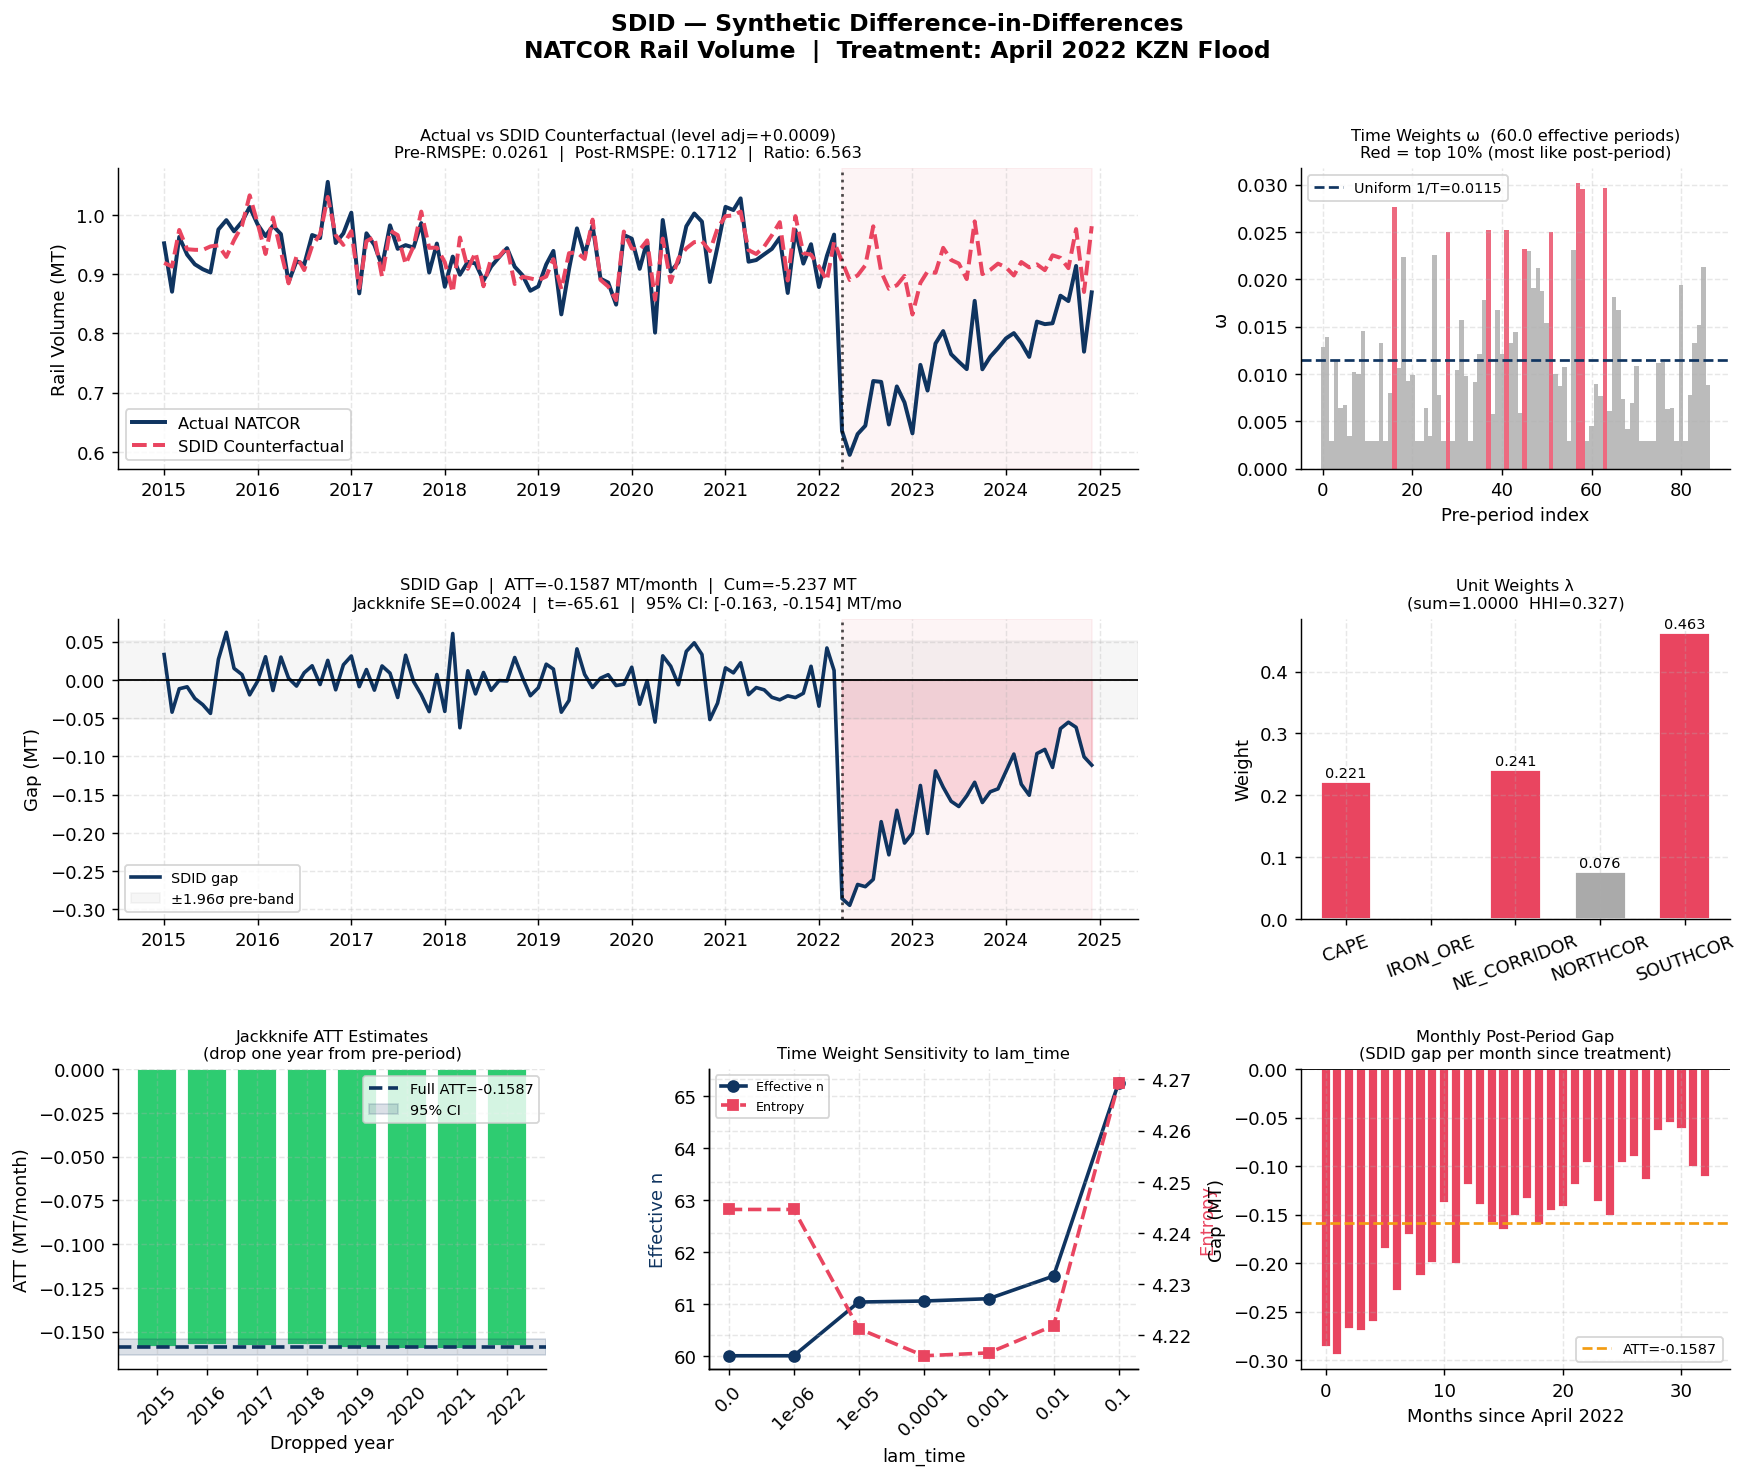

Saved → ../method_A_graph/sdid_fig1_main_panel.png


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Figure 1: Main Diagnostic Panel
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, hspace=0.50, wspace=0.38)

# ── Plot 1: Actual vs SDID counterfactual ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(t_stamps, Y_all,       color=BLUE, lw=2.2, label='Actual NATCOR')
ax1.plot(t_stamps, cf_sdid,     color=RED,  lw=2.2, ls='--', label='SDID Counterfactual')
ax1.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.7)
ax1.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
ax1.set_title(
    f'Actual vs SDID Counterfactual (level adj={level_adj:+.4f})\n'
    f'Pre-RMSPE: {sdid_pre_r:.4f}  |  Post-RMSPE: {sdid_post_r:.4f}  |  Ratio: {sdid_ratio:.3f}',
    fontsize=9)
ax1.set_ylabel('Rail Volume (MT)')
ax1.legend(fontsize=9)

# ── Plot 2: Time weights ω ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
top10_thresh = np.percentile(omega, 90)
bar_colors   = [RED if w > top10_thresh else GREY for w in omega]
ax2.bar(range(T_pre), omega, color=bar_colors, width=1.0, edgecolor='none', alpha=0.8)
ax2.axhline(1/T_pre, color=BLUE, lw=1.5, ls='--', label=f'Uniform 1/T={1/T_pre:.4f}')
ax2.set_title(f'Time Weights ω  ({effective_n(omega):.1f} effective periods)\nRed = top 10% (most like post-period)', fontsize=9)
ax2.set_xlabel('Pre-period index')
ax2.set_ylabel('ω')
ax2.legend(fontsize=8)

# ── Plot 3: Unit weights λ ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
bar_c3 = [RED if w > 0.1 else GREY for w in lam_unit]
bars3  = ax3.bar(donors, lam_unit, color=bar_c3, edgecolor='white', width=0.6)
for bar, w in zip(bars3, lam_unit):
    if w > 0.01:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{w:.3f}', ha='center', va='bottom', fontsize=8)
ax3.set_title(f'Unit Weights λ\n(sum={lam_unit.sum():.4f}  HHI={np.sum((lam_unit/lam_unit.sum())**2):.3f})', fontsize=9)
ax3.set_ylabel('Weight')
ax3.tick_params(axis='x', rotation=20)

# ── Plot 4: SDID gap ──────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
ax4.plot(t_stamps, gap_sdid, color=BLUE, lw=2, label='SDID gap')
ax4.axhline(0, color='black', lw=1)
ax4.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.7)
ax4.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
ax4.fill_between(
    t_stamps, gap_sdid, 0,
    where=[p >= TREAT_START for p in wide.index],
    alpha=0.18, color=RED if sdid_cum < 0 else BLUE)
ci_pre = 1.96 * gap_sdid[:T_pre].std()
ax4.axhspan(-ci_pre, ci_pre, alpha=0.10, color=GREY, label=f'±1.96σ pre-band')
ax4.set_title(
    f'SDID Gap  |  ATT={tau_sdid:.4f} MT/month  |  Cum={sdid_cum:.3f} MT\n'
    f'Jackknife SE={jk_se:.4f}  |  t={t_stat:.2f}  |  95% CI: [{ci95_lo:.3f}, {ci95_hi:.3f}] MT/mo',
    fontsize=9)
ax4.set_ylabel('Gap (MT)')
ax4.legend(fontsize=8)

# ── Plot 5: Jackknife ATTs ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
if len(jk_df) > 0:
    bar_c5 = [GREEN if abs(v - tau_sdid) < jk_se else RED for v in jk_df['ATT']]
    ax5.bar(jk_df['Drop year'].astype(str), jk_df['ATT'], color=bar_c5, edgecolor='white')
    ax5.axhline(tau_sdid, color=BLUE, lw=2, ls='--', label=f'Full ATT={tau_sdid:.4f}')
    ax5.axhspan(ci95_lo, ci95_hi, alpha=0.15, color=BLUE, label='95% CI')
    ax5.set_title('Jackknife ATT Estimates\n(drop one year from pre-period)', fontsize=9)
    ax5.set_ylabel('ATT (MT/month)')
    ax5.set_xlabel('Dropped year')
    ax5.legend(fontsize=8)
    ax5.tick_params(axis='x', rotation=45)

# ── Plot 6: Time weight sensitivity ──────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
lam_labels = [str(l) for l in lam_time_grid]
eff_ns_plot = [effective_n(omega_results[l]) for l in lam_time_grid]
entropies   = [entropy(omega_results[l]) for l in lam_time_grid]
ax6.plot(lam_labels, eff_ns_plot, color=BLUE, lw=2, marker='o', ms=6, label='Effective n')
ax6b = ax6.twinx()
ax6b.plot(lam_labels, entropies, color=RED, lw=2, marker='s', ms=6, ls='--', label='Entropy')
ax6.set_title('Time Weight Sensitivity to lam_time', fontsize=9)
ax6.set_xlabel('lam_time')
ax6.set_ylabel('Effective n', color=BLUE)
ax6b.set_ylabel('Entropy', color=RED)
ax6.tick_params(axis='x', rotation=45)
lines1, labs1 = ax6.get_legend_handles_labels()
lines2, labs2 = ax6b.get_legend_handles_labels()
ax6.legend(lines1 + lines2, labs1 + labs2, fontsize=7)

# ── Plot 7: Monthly post-period effect bars ───────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
post_gaps = gap_sdid[T_pre:]
bar_c7 = [RED if v < 0 else BLUE for v in post_gaps]
ax7.bar(np.arange(T_post), post_gaps, color=bar_c7, edgecolor='white', width=0.85)
ax7.axhline(0, color='black', lw=1)
ax7.axhline(tau_sdid, color=AMBER, lw=1.5, ls='--', label=f'ATT={tau_sdid:.4f}')
ax7.set_title('Monthly Post-Period Gap\n(SDID gap per month since treatment)', fontsize=9)
ax7.set_xlabel('Months since April 2022')
ax7.set_ylabel('Gap (MT)')
ax7.legend(fontsize=8)

fig.suptitle(
    'SDID — Synthetic Difference-in-Differences\n'
    'NATCOR Rail Volume  |  Treatment: April 2022 KZN Flood',
    fontsize=13, fontweight='bold')
save_path = os.path.join(FIG_DIR, 'sdid_fig1_main_panel.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

**What is happening here**  
A seven-panel diagnostic figure is produced.

- **Top-left** — Actual vs SDID counterfactual across the full timeline.
- **Top-right** — The time weights ω as a bar chart. Red bars are the top 10% most comparable pre-months. If these cluster in recent years, it means only recent pre-flood history is being used as the comparison baseline.
- **Middle-right** — Unit weights λ. With 5 donors, this shows the real corridor allocation.
- **Middle-left** — The treatment gap with the grey pre-period noise band and the full inference summary in the title.
- **Bottom-left** — Jackknife ATT estimates by dropped year with the 95% CI band.
- **Bottom-middle** — How the effective number of time periods and entropy change as lam_time varies.
- **Bottom-right** — Monthly post-flood effects as a bar chart, with the ATT line for reference.

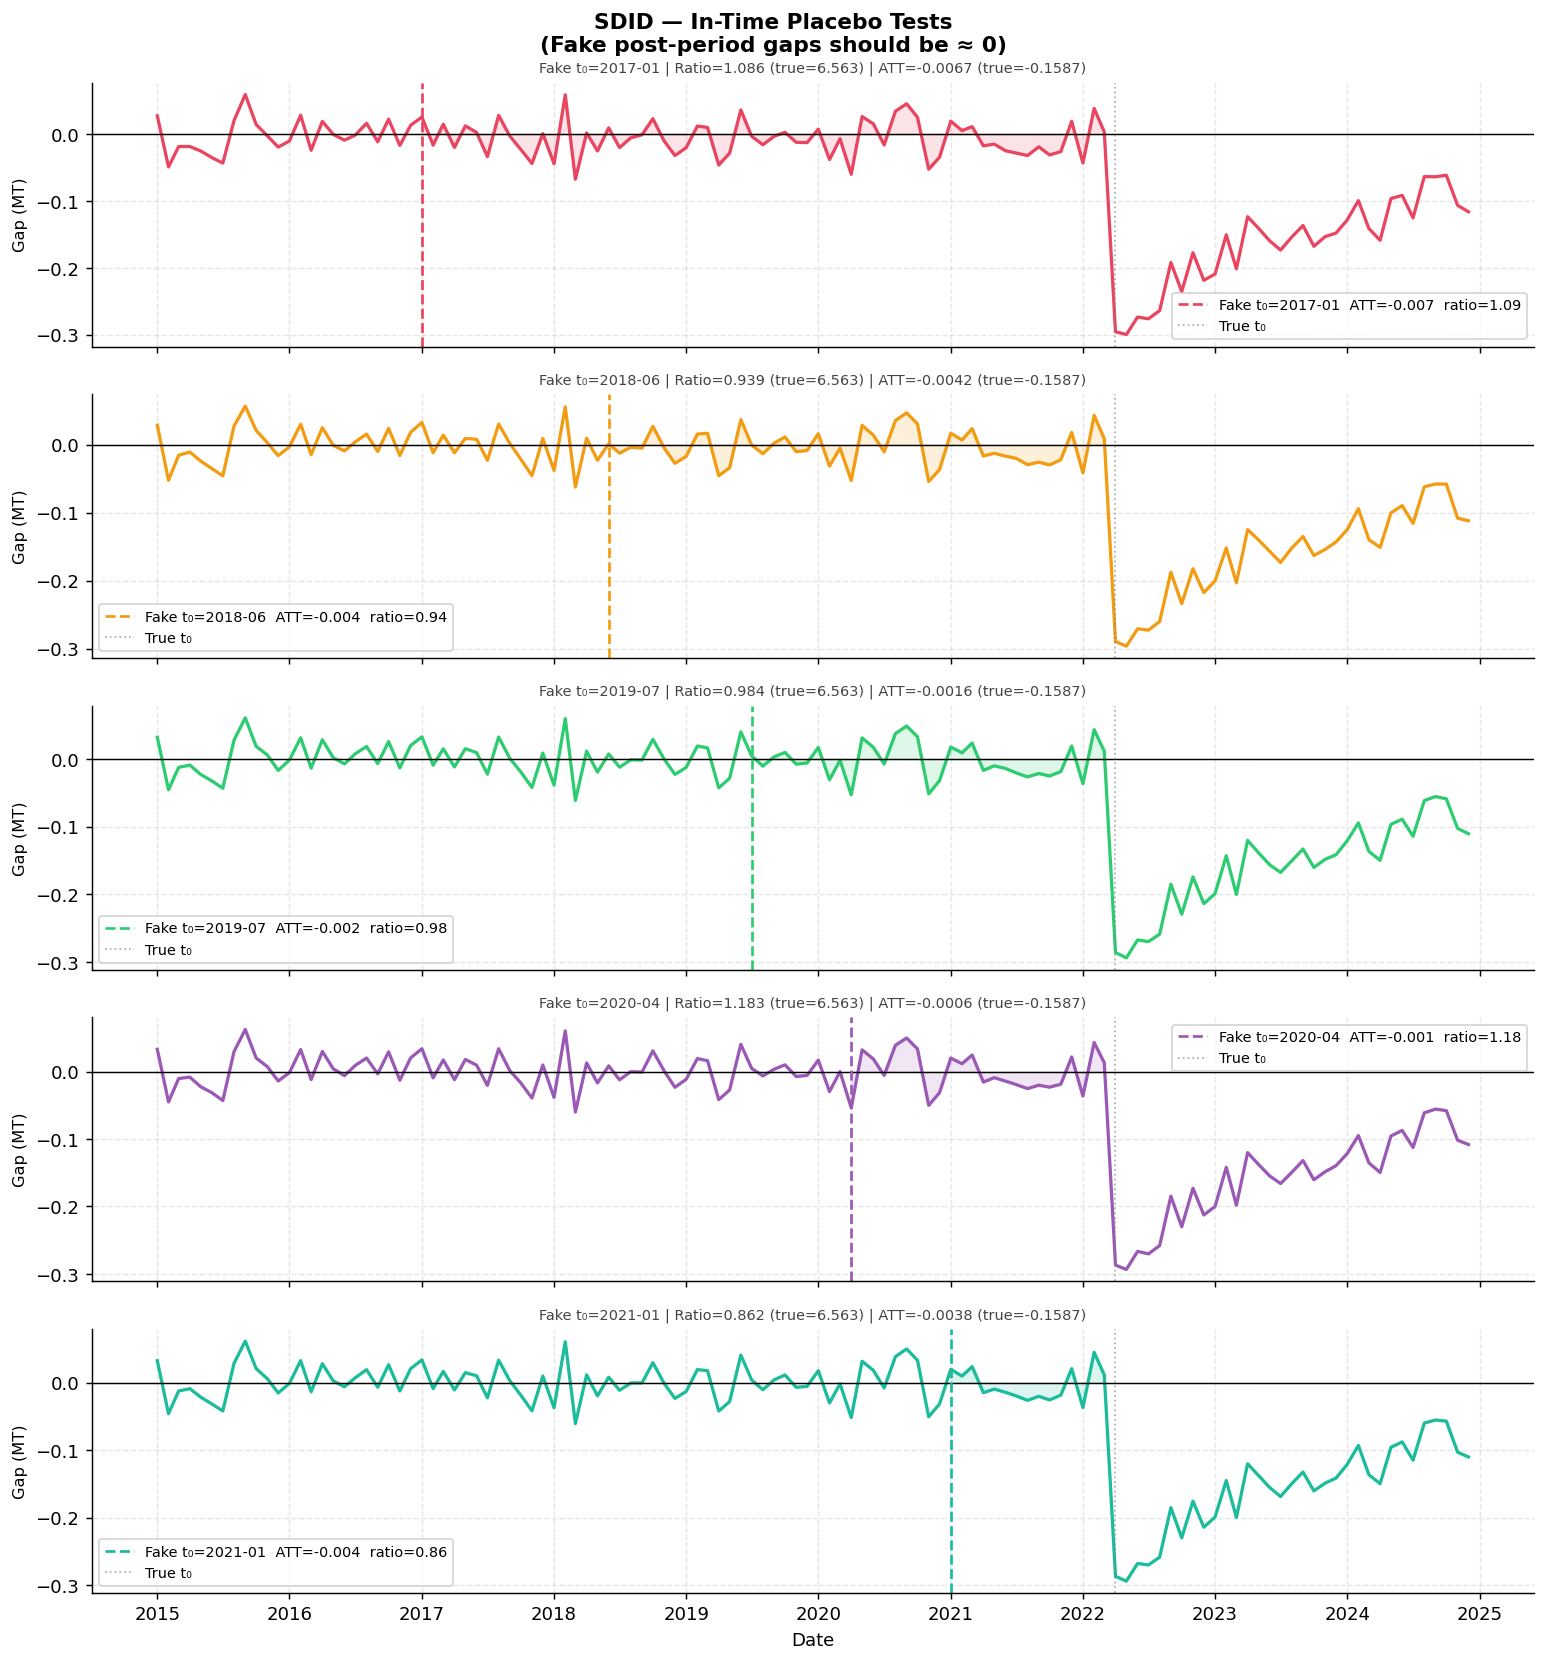

Saved → ../method_A_graph/sdid_fig2_placebo.png

Fake t₀      ATT  Pre-RMSPE  Post-RMSPE  Ratio  > True
2017-01 -0.00669    0.02531     0.02747  1.086   False
2018-06 -0.00424    0.02735     0.02568  0.939   False
2019-07 -0.00160    0.02629     0.02586  0.984   False
2020-04 -0.00064    0.02483     0.02937  1.183   False
2021-01 -0.00384    0.02676     0.02307  0.862   False

True SDID ratio: 6.5629  |  True ATT: -0.1587
Placebo ratios > true: 0 / 5


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Validation A: In-Time Placebo Tests
# ═══════════════════════════════════════════════════════════════════════════════

placebo_dates  = [pd.Period(d, freq='M') for d in
                  ['2017-01', '2018-06', '2019-07', '2020-04', '2021-01']]
placebo_colors = [RED, AMBER, GREEN, PURP, '#1abc9c']
placebo_records = []

fig, axes = plt.subplots(len(placebo_dates), 1, figsize=(12, 13), sharex=True)
fig.suptitle(
    'SDID — In-Time Placebo Tests\n(Fake post-period gaps should be ≈ 0)',
    fontsize=12, fontweight='bold')

for i, fake_t in enumerate(placebo_dates):
    fake_pre  = wide.index[wide.index <= (fake_t - 1)]
    fake_post = wide.index[(wide.index >= fake_t) & (wide.index < TREAT_START)]
    if len(fake_pre) < 12 or len(fake_post) < 6:
        continue

    Y_fp   = wide.loc[fake_pre, TREATED].values
    X_fp   = wide.loc[fake_pre, donors].values
    X_fpost = wide.loc[fake_post, donors].values
    Y_fpost = wide.loc[fake_post, TREATED].values

    omega_fp = fit_time_weights(X_fp, X_fpost, lam_t=LAM_TIME_DEFAULT)
    lam_fp   = fit_unit_weights(Y_fp, X_fp)

    lvl_fp   = (omega_fp @ Y_fp) - lam_fp @ (X_fp.T @ omega_fp)
    cf_fp    = X_all @ lam_fp + lvl_fp
    gap_fp   = Y_all - cf_fp

    T_fp     = len(fake_pre)
    pre_r_fp = rmspe(Y_fp, cf_fp[:T_fp])
    post_idxs = slice(T_fp, T_fp + len(fake_post))
    post_r_fp = rmspe(Y_fpost, cf_fp[T_fp:T_fp + len(fake_post)])
    ratio_fp  = post_r_fp / pre_r_fp if pre_r_fp > 0 else np.nan
    tau_fp    = (Y_fpost.mean() - omega_fp @ Y_fp) - lam_fp @ (X_fpost.mean(axis=0) - X_fp.T @ omega_fp)

    placebo_records.append({
        'Fake t₀':    str(fake_t),
        'ATT':        round(tau_fp, 5),
        'Pre-RMSPE':  round(pre_r_fp, 5),
        'Post-RMSPE': round(post_r_fp, 5),
        'Ratio':      round(ratio_fp, 3),
        '> True':     ratio_fp > sdid_ratio
    })

    in_fp = np.array([(p >= fake_t and p < TREAT_START) for p in wide.index])
    ax = axes[i]
    ax.plot(t_stamps, gap_fp, color=placebo_colors[i], lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(fake_t.to_timestamp(), color=placebo_colors[i], lw=1.5, ls='--',
               label=f'Fake t₀={fake_t}  ATT={tau_fp:.3f}  ratio={ratio_fp:.2f}')
    ax.axvline(treat_t, color='grey', lw=1, ls=':', alpha=0.6, label='True t₀')
    ax.fill_between(t_stamps, gap_fp, 0, where=in_fp, alpha=0.15, color=placebo_colors[i])
    ax.set_ylabel('Gap (MT)', fontsize=9)
    ax.legend(fontsize=8)
    ax.set_title(
        f'Fake t₀={fake_t} | Ratio={ratio_fp:.3f} (true={sdid_ratio:.3f}) | ATT={tau_fp:.4f} (true={tau_sdid:.4f})',
        fontsize=8, color='#444')

axes[-1].set_xlabel('Date')
plt.tight_layout()
save_path = os.path.join(FIG_DIR, 'sdid_fig2_placebo.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")
print()

p_df = pd.DataFrame(placebo_records)
print(p_df.to_string(index=False))
print(f"\nTrue SDID ratio: {sdid_ratio:.4f}  |  True ATT: {tau_sdid:.4f}")
n_exceed = p_df['> True'].sum()
print(f"Placebo ratios > true: {n_exceed} / {len(p_df)}")

**What is happening here**  
In-time placebo tests are run using fake treatment dates. For each fake date, new time weights and unit weights are estimated using only the data available before that fake date, and the SDID ATT is recomputed. Small placebo ATTs and low post/pre ratios confirm the model is not spuriously detecting shocks.

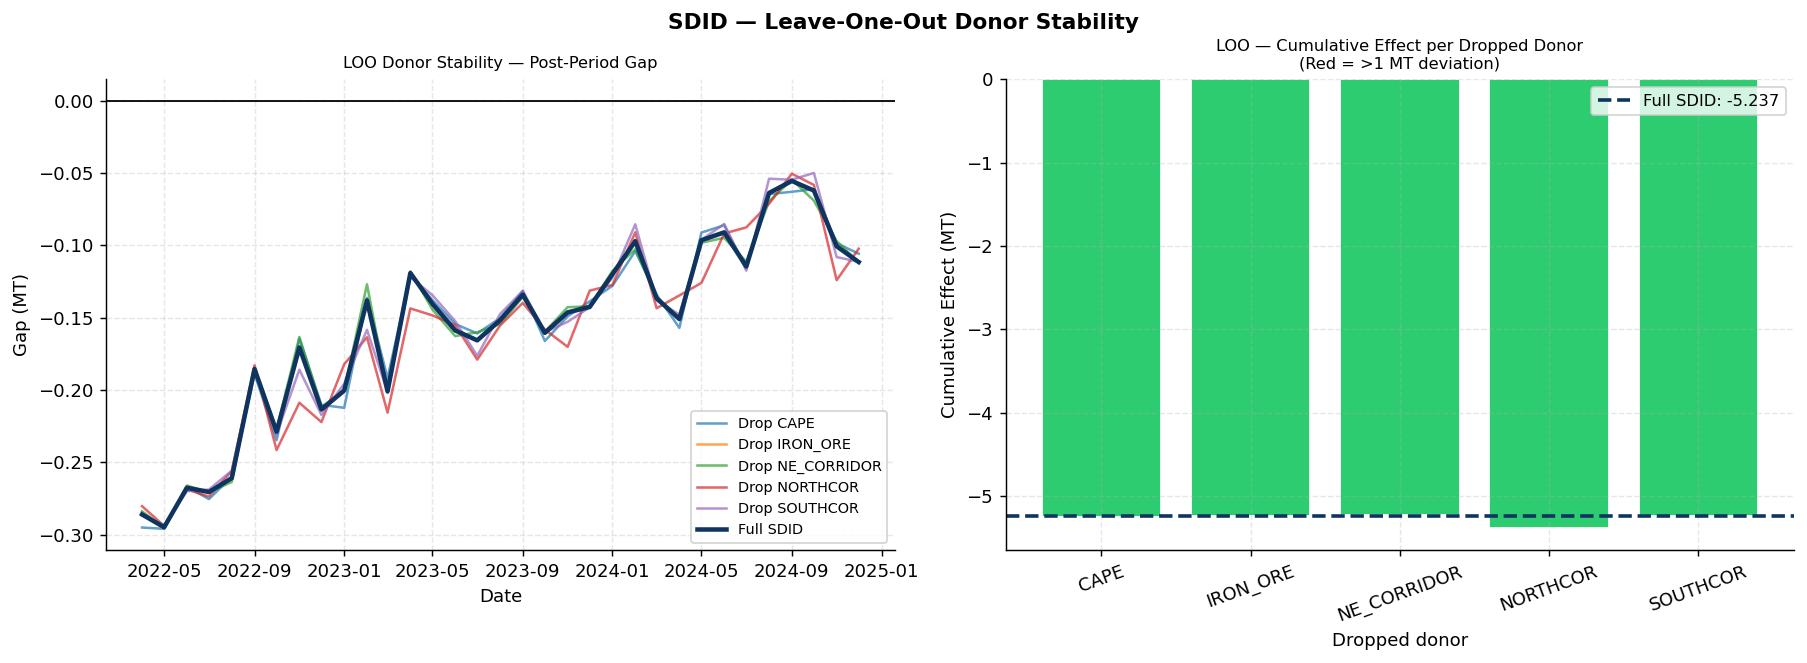

Saved → ../method_A_graph/sdid_fig3_loo.png

LOO Summary:
    Dropped  Pre-RMSPE  Post-RMSPE  Ratio  Cum effect
       CAPE    0.02676     0.17191 6.4245     -5.2495
   IRON_ORE    0.02608     0.17112 6.5612     -5.2345
NE_CORRIDOR    0.02628     0.17071 6.4971     -5.2286
   NORTHCOR    0.03122     0.17531 5.6152     -5.3780
   SOUTHCOR    0.02669     0.17175 6.4347     -5.2389

Full SDID cumulative effect : -5.2366 MT
LOO spread                  : 0.1494 MT


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Validation B: Leave-One-Out Donor Stability
# ═══════════════════════════════════════════════════════════════════════════════

loo_records = []
fig, axes   = plt.subplots(1, 2, figsize=(14, 5))
ax_gap, ax_bar = axes
cmap = plt.cm.tab10

for j, drop_d in enumerate(donors):
    keep_donors  = [d for d in donors if d != drop_d]
    X_pre_loo    = wide.loc[pre_idx,  keep_donors].values
    X_post_loo   = wide.loc[post_idx, keep_donors].values
    X_all_loo    = wide[keep_donors].values

    omega_loo = fit_time_weights(X_pre_loo, X_post_loo, lam_t=LAM_TIME_DEFAULT)
    lam_loo   = fit_unit_weights(Y_pre_v, X_pre_loo)

    lvl_loo   = (omega_loo @ Y_pre_v) - lam_loo @ (X_pre_loo.T @ omega_loo)
    cf_loo    = X_all_loo @ lam_loo + lvl_loo
    gap_loo   = Y_all - cf_loo

    cum_loo    = gap_loo[T_pre:].sum()
    pre_r_loo  = rmspe(Y_all[:T_pre], cf_loo[:T_pre])
    post_r_loo = rmspe(Y_all[T_pre:], cf_loo[T_pre:])
    ratio_loo  = post_r_loo / pre_r_loo

    loo_records.append({
        'Dropped': drop_d,
        'Pre-RMSPE':  round(pre_r_loo,  5),
        'Post-RMSPE': round(post_r_loo, 5),
        'Ratio':      round(ratio_loo,  4),
        'Cum effect': round(cum_loo,    4)
    })
    ax_gap.plot(t_stamps[T_pre:], gap_loo[T_pre:],
                color=cmap(j), alpha=0.7, lw=1.4, label=f'Drop {drop_d}')

ax_gap.plot(t_stamps[T_pre:], gap_sdid[T_pre:], color=BLUE, lw=2.5, label='Full SDID', zorder=5)
ax_gap.axhline(0, color='black', lw=1)
ax_gap.set_title('LOO Donor Stability — Post-Period Gap', fontsize=9)
ax_gap.set_ylabel('Gap (MT)')
ax_gap.set_xlabel('Date')
ax_gap.legend(fontsize=8)

loo_df     = pd.DataFrame(loo_records)
deviations = abs(loo_df['Cum effect'] - sdid_cum)
bar_cols   = [RED if d > 1.0 else GREEN for d in deviations]
ax_bar.bar(loo_df['Dropped'], loo_df['Cum effect'], color=bar_cols, edgecolor='white')
ax_bar.axhline(sdid_cum, color=BLUE, lw=2, ls='--', label=f'Full SDID: {sdid_cum:.3f}')
ax_bar.set_title('LOO — Cumulative Effect per Dropped Donor\n(Red = >1 MT deviation)', fontsize=9)
ax_bar.set_ylabel('Cumulative Effect (MT)')
ax_bar.set_xlabel('Dropped donor')
ax_bar.legend(fontsize=9)
ax_bar.tick_params(axis='x', rotation=20)

plt.tight_layout()
fig.suptitle('SDID — Leave-One-Out Donor Stability', fontsize=12, fontweight='bold', y=1.01)
save_path = os.path.join(FIG_DIR, 'sdid_fig3_loo.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")
print()
print("LOO Summary:")
print(loo_df.to_string(index=False))
loo_spread = loo_df['Cum effect'].max() - loo_df['Cum effect'].min()
print(f"\nFull SDID cumulative effect : {sdid_cum:.4f} MT")
print(f"LOO spread                  : {loo_spread:.4f} MT")

**What is happening here**  
Each donor is removed one at a time and the full SDID is re-estimated with the remaining four. Both unit weights and time weights are re-computed from scratch for each LOO configuration. This tests whether any single corridor is disproportionately driving the flood effect estimate. A tight LOO spread means the result is robust to the specific choice of donor pool.

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — Final Summary Table
# ═══════════════════════════════════════════════════════════════════════════════

summary_rows = [
    ('Method',                     'SDID'),
    ('Donors',                     str(len(donors))),
    ('lam_time',                   str(LAM_TIME_DEFAULT)),
    ('Unit weights (λ)',           str(dict(zip(donors, lam_unit.round(4))))),
    ('Level adjustment (MT)',      f'{level_adj:+.6f}'),
    ('Effective time periods (ω)', f'{effective_n(omega):.2f} / {T_pre}'),
    ('ω entropy',                  f'{entropy(omega):.4f}  (max={np.log(T_pre):.4f})'),
    ('Pre-RMSPE',                  f'{sdid_pre_r:.6f}'),
    ('Post-RMSPE',                 f'{sdid_post_r:.6f}'),
    ('Post/Pre ratio',             f'{sdid_ratio:.4f}'),
    ('Ratio > 1',                  str(sdid_ratio > 1)),
    ('ATT (monthly)',              f'{tau_sdid:+.6f} MT/month'),
    ('Cumulative effect (MT)',     f'{sdid_cum:.4f}'),
    ('Avg monthly effect (MT)',    f'{sdid_avg:.4f}'),
    ('Post MAPE (%)',              f'{sdid_mape:.2f}'),
    ('Jackknife SE',               f'{jk_se:.6f}'),
    ('t-statistic',                f'{t_stat:.3f}'),
    ('95% CI (ATT monthly)',       f'[{ci95_lo:.4f}, {ci95_hi:.4f}]'),
    ('95% CI cumulative (MT)',     f'[{ci95_lo*T_post:.3f}, {ci95_hi*T_post:.3f}]'),
    ('Significant at 95%',        str(abs(t_stat) > 1.96)),
    ('Placebo exceedances',        f'{n_exceed} / {len(p_df)}'),
    ('LOO donor spread (MT)',      f'{loo_spread:.4f}'),
]

print("═" * 62)
print("SDID — FINAL SUMMARY")
print("═" * 62)
for row in summary_rows:
    print(f"  {row[0]:<34} {row[1]}")
print("═" * 62)
print()
print("Interpretation:")

if abs(t_stat) > 1.96:
    print(f"  ✓ t={t_stat:.3f} — ATT is statistically significant at 95% level.")
else:
    print(f"  ~ t={t_stat:.3f} — ATT not significant at 95% (|t| < 1.96).")

if sdid_ratio > 1:
    print(f"  ✓ Ratio {sdid_ratio:.3f} > 1 — post-period divergence exceeds pre-period noise.")
else:
    print(f"  ✗ Ratio {sdid_ratio:.3f} ≤ 1.")

if n_exceed == 0:
    print(f"  ✓ 0 placebo exceedances — April 2022 shock is uniquely large.")
else:
    print(f"  ~ {n_exceed} placebo(s) exceed true ratio.")

if loo_spread < 1.0:
    print(f"  ✓ LOO spread ({loo_spread:.4f} MT) is small — stable across donor pool.")
else:
    print(f"  ~ LOO spread ({loo_spread:.4f} MT) is moderate — some donor sensitivity.")

print(f"\n  SDID is the only method in this series with formal inference (jackknife SE).")
print(f"  ATT = {tau_sdid:+.4f} MT/month  →  cumulative = {sdid_cum:.4f} MT over {T_post} months.")

══════════════════════════════════════════════════════════════
SDID — FINAL SUMMARY
══════════════════════════════════════════════════════════════
  Method                             SDID
  Donors                             5
  lam_time                           1e-06
  Unit weights (λ)                   {'CAPE': np.float64(0.2211), 'IRON_ORE': np.float64(0.0), 'NE_CORRIDOR': np.float64(0.2408), 'NORTHCOR': np.float64(0.0756), 'SOUTHCOR': np.float64(0.4625)}
  Level adjustment (MT)              +0.000880
  Effective time periods (ω)         60.01 / 87
  ω entropy                          4.2446  (max=4.4659)
  Pre-RMSPE                          0.026083
  Post-RMSPE                         0.171180
  Post/Pre ratio                     6.5629
  Ratio > 1                          True
  ATT (monthly)                      -0.158684 MT/month
  Cumulative effect (MT)             -5.2366
  Avg monthly effect (MT)            -0.1587
  Post MAPE (%)                      22.11
  Jackknife SE 

**What is happening here**  
All results are collected into a final summary table with automatic checks. The key distinction of SDID compared with Methods A, B, and C is the formal inference: SDID provides an actual t-statistic and confidence interval (via the jackknife SE), not just a descriptive ratio. The cumulative CI at the bottom tells us the range of plausible total flood impacts at 95% confidence.